# Gini y entropía sobre una misma variable

**Almacenes y Minería de Datos · Práctica 4**

Este notebook aplica la entropía de Shannon y el coeficiente de Gini a las frecuencias de una misma variable cualitativa, para comparar lo que dice cada uno. Los índices provienen de `src/visualization/indices.py` y la figura de `src/visualization/graficas.py`; aquí solo se presentan los resultados y su interpretación.

## 1. Dos lecturas de una misma distribución

Los notebooks anteriores usaron la entropía de Shannon para medir heterogeneidad y el coeficiente de Gini para medir concentración. Los dos se pueden calcular sobre las mismas frecuencias, y es frecuente confundirlos porque ambos resumen qué tan parejo es un reparto. No miden lo mismo.

Sea $k$ el número de categorías, $f_i$ la frecuencia de la categoría $i$ y $p_i$ su proporción del total.

La entropía es $H = -\sum_{i=1}^{k} p_i \log_2 p_i$.

El Gini de las frecuencias trata a las categorías como unidades y a su frecuencia como la cantidad que se reparte. Usa la misma fórmula del notebook de medidas de concentración, con las frecuencias ordenadas de menor a mayor:

$$G = \frac{2\sum_{i=1}^{k} i\,f_{(i)} - (k+1)\sum_{i=1}^{k} f_{(i)}}{k\sum_{i=1}^{k} f_{(i)}}$$

| | Entropía de Shannon | Gini de las frecuencias |
|---|---|---|
| Familia | Heterogeneidad | Concentración |
| Pregunta que responde | Qué tan repartidos están los casos entre las categorías | Qué tan desiguales son los tamaños de las categorías |
| Con todas las categorías iguales | Alcanza su máximo, $\log_2 k$ | Vale 0 |
| Con todo en una categoría | Vale 0 | Alcanza su máximo, $\frac{k-1}{k}$ |

Los dos índices van en sentido contrario: la entropía crece cuando la distribución se acerca al reparto igual y el Gini crece cuando se aleja de él. Tampoco comparten escala. Con seis categorías la entropía puede llegar a $\log_2 6 = 2.5850$ bits y el Gini a $\frac{5}{6} = 0.8333$. Para leerlos juntos, cada valor se acompaña de su máximo y de la fracción de ese máximo que representa.

Las frecuencias se toman de la población estimada: la frecuencia de una categoría es la suma del factor de expansión de sus registros.

## 2. Datos

Se parte del archivo que produce `src/cleaning/limpieza.py`. La variable elegida es el estado conyugal, `estado_civil_desc`, que tiene seis categorías de significado conocido y valor en todos los registros. El enunciado propone como ejemplo una variable de tipo de violencia, que el archivo consolidado no incluye.

In [1]:
import sys
from pathlib import Path

import polars as pl
from IPython.display import Image, display

# La raíz del proyecto entra al path para importar config/ y src/.
RAIZ = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
sys.path.append(str(RAIZ))

from config.rutas import RUTA_ENDIREH_LIMPIO, RUTA_FIGURAS
from src.visualization.graficas import figura_10_sintesis_estado_conyugal
from src.visualization.indices import seccion_sintesis

df = pl.read_parquet(RUTA_ENDIREH_LIMPIO)

print(f"Registros: {df.height:,}")
print(f"Población representada: {df['factor_expansion'].sum():,.0f} mujeres de 15 años y más")

Registros: 105,752
Población representada: 49,144,897 mujeres de 15 años y más


## 3. Resultados

### 3.1 Población por estado conyugal

In [2]:
seccion_sintesis(df)


 GINI Y ENTROPÍA DE estado_civil_desc (población estimada)

    Categoría                  Mujeres   Proporción
    -----------------------------------------------
    Divorciada               1,343,966         2.7%
    Separada                 4,307,120         8.8%
    Viuda                    4,392,463         8.9%
    Unión libre              9,057,408        18.4%
    Soltera                 12,831,300        26.1%
    Casada                  17,212,640        35.0%

    Índice                            Valor    Máximo    Valor / máximo
    -------------------------------------------------------------------
    Entropía de Shannon (bits)       2.2468    2.5850            0.8692
    Gini de las frecuencias          0.3716    0.8333            0.4460


**Interpretación.** La entropía es de 2.2468 bits, el 86.9 % de su máximo. Leída sola, indica una distribución cercana al reparto igual: la población está repartida entre varios estados conyugales y ninguno reúne a la mayoría.

El Gini de las frecuencias es de 0.3716, el 44.6 % de su máximo. Leído solo, indica que los tamaños de las categorías son bastante desiguales: las casadas son el 35.0 % de la población y las divorciadas el 2.7 %, y las tres categorías mayores suman el 79.5 %.

Las dos lecturas son compatibles. La población se reparte entre varias categorías, y por eso la entropía es alta. Esas categorías no pesan lo mismo, y por eso el Gini no es bajo.

### 3.2 Diferencia entre los dos índices

La entropía y el Gini resumen las mismas seis proporciones con preguntas distintas. La entropía mide heterogeneidad: cuánta incertidumbre hay sobre el estado conyugal de una mujer tomada al azar, y por eso sube cuando la población se reparte entre más categorías de peso parecido. El Gini mide concentración: qué tan desigual es el tamaño de las categorías, y por eso sube cuando unas pocas reúnen la mayor parte. En el estado conyugal la entropía es de 2.2468 bits sobre un máximo de 2.5850 y el Gini de 0.3716 sobre un máximo de 0.8333. Los máximos son distintos y los índices van en sentido contrario, de modo que sus valores no se comparan directamente: la entropía alta dice que no hay una categoría dominante, y el Gini intermedio dice que, aun así, el reparto está lejos de ser parejo. Ninguno sustituye al otro, porque describen aspectos distintos de la misma distribución.

### 3.3 La misma lectura sobre los casos

Los dos índices se pueden aplicar también a los casos de violencia de pareja reportada, que es lo más cercano en este conjunto a medir cómo se reparte la violencia entre categorías.

In [3]:
seccion_sintesis(df, solo_casos=True)


 GINI Y ENTROPÍA DE estado_civil_desc (casos de violencia reportada)

    Categoría                  Mujeres   Proporción
    -----------------------------------------------
    Divorciada                 597,378         6.8%
    Viuda                      994,420        11.3%
    Unión libre              1,340,878        15.3%
    Soltera                  1,451,542        16.6%
    Separada                 1,967,862        22.4%
    Casada                   2,418,414        27.6%

    Índice                            Valor    Máximo    Valor / máximo
    -------------------------------------------------------------------
    Entropía de Shannon (bits)       2.4601    2.5850            0.9517
    Gini de las frecuencias          0.2306    0.8333            0.2767


**Interpretación.** Entre los casos la entropía sube a 2.4601 bits y el Gini baja a 0.2306. Los casos están más repartidos entre los estados conyugales que la población, y los dos índices registran ese cambio, cada uno en su sentido.

La razón está en las proporciones. Las mujeres separadas son el 8.8 % de la población y el 22.4 % de los casos, y las divorciadas pasan del 2.7 % al 6.8 %, mientras que las casadas bajan del 35.0 % al 27.6 %.

Esta comparación describe lo que las encuestadas reportaron. No permite concluir que separarse o divorciarse cause violencia, ni lo contrario, porque la encuesta registra el estado conyugal y la violencia en un mismo momento.

### 3.4 Las dos distribuciones frente al reparto igual

[graficas] reports/figuras/10_estado_conyugal_poblacion_y_casos.png


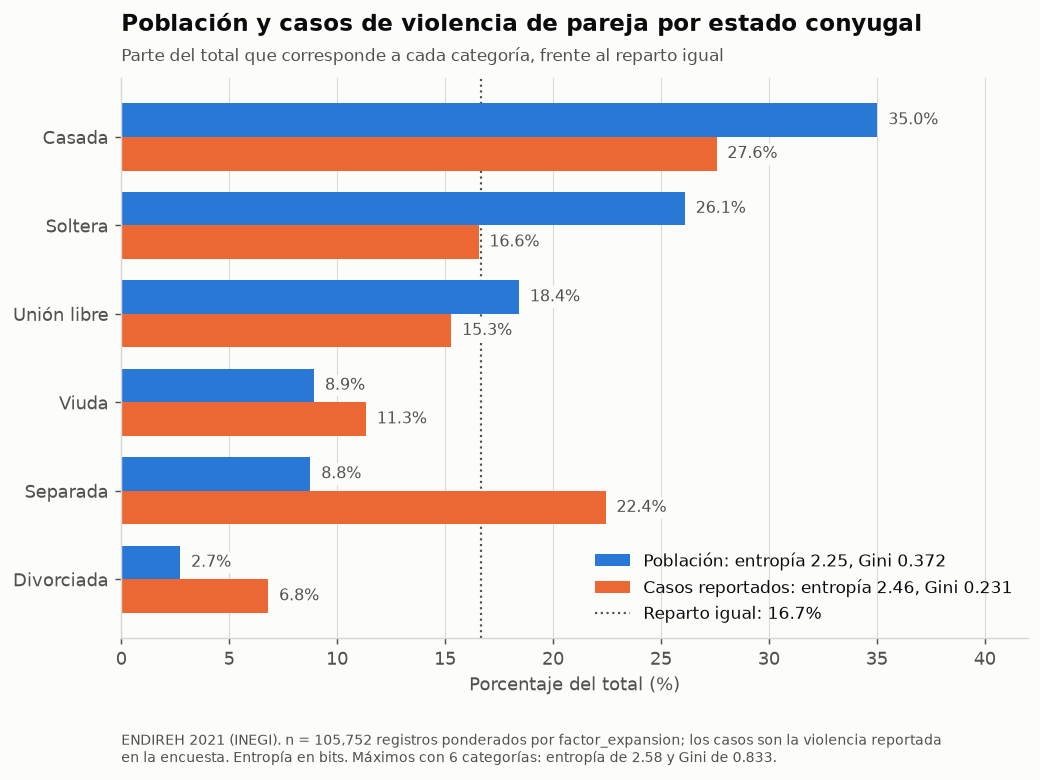

In [4]:
figura_10_sintesis_estado_conyugal(df)
display(Image(filename=str(RUTA_FIGURAS / "10_estado_conyugal_poblacion_y_casos.png")))

**Interpretación.** La línea punteada marca el reparto igual, de 16.7 % por categoría. En la población tres categorías quedan por encima de esa línea y tres muy por debajo. En los casos las barras se acercan más a la línea, que es lo que expresan una entropía mayor y un Gini menor.

## 4. Valor para la tabla del reporte

En la fila de síntesis de la tabla de resultados se usa `estado_civil_desc`, con una entropía de 2.2468 bits sobre un máximo de 2.5850 y un Gini de las frecuencias de 0.3716 sobre un máximo de 0.8333.

La lectura es que la población se reparte entre varios estados conyugales sin que uno domine, pero con categorías de tamaño desigual. Entre los casos de violencia de pareja reportada el reparto es más parejo, con 2.4601 bits y un Gini de 0.2306, porque las mujeres separadas y divorciadas pesan más en los casos que en la población. Se trata de una asociación observada en lo reportado y no de una relación causal.